# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Проверка гипотезы о различии пользовательской активности в Москве и Санкт-Петербурге

- Автор: Ребрикова Мария
- Дата: 22.04.2026

## Цели и задачи проекта

**Цель проекта:**
проверить гипотезу о различии пользовательского поведения в сервисе Яндекс Книги, а именно: определить, проводят ли пользователи из Санкт-Петербурга в среднем больше времени за чтением и прослушиванием контента, чем пользователи из Москвы, и оценить статистическую значимость этого различия.

**Задачи проекта:**

- провести предобработку и проверку данных 
- сравнить размеры групп пользователей и их основные статистические характеристики
- проанализировать распределение времени активности пользователей в двух городах
- сформулировать и проверить статистическую гипотезу с использованием t-теста 
- интерпретировать результаты статистического теста
- предложить возможные причины выявленных различий в пользовательском поведении.

## Описание данных

В рамках проекта используется датасет `/datasets/yandex_knigi_data.csv`, содержащий данные об активности пользователей сервиса Яндекс Книги.

Данные были предварительно обработаны на этапе SQL.

В датасете содержатся следующие поля:

- `city` -- город пользователя (Москва или Санкт-Петербург)

- `puid` -- уникальный идентификатор пользователя

- `hour` -- суммарное время активности пользователя в часах.

Данные используются для сравнения пользовательской активности между двумя группами пользователей и последующей проверки статистической гипотезы.

## Содержимое проекта

В рамках проекта были выполнены следующие шаги:

- Загрузка и первичный анализ данных
- Проверка данных на наличие дубликатов и их обработка
- Сравнение размеров групп пользователей
- Анализ статистических характеристик 
- Исследование распределения времени активности пользователей
- Формулировка и проверка статистической гипотезы с использованием t-теста
- Интерпретация результатов и подготовка аналитической записки.

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd

In [2]:
# загрузка данных
df = pd.read_csv('/datasets/yandex_knigi_data.csv')

In [3]:
# первые строки
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


Столбец `Unnamed: 0` не несет никакой аналитической ценности, поэтому сразу уберем его.

In [4]:
df = df.drop(columns=['Unnamed: 0'])

In [5]:
# информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB


Датасет содержит 8784 строки и включает три столбца: город пользователя, его идентификатор и суммарное время активности. Пропуски в данных отсутствуют.

### 1.1 Проверка дубликатов

In [6]:
duplicates = df['puid'].duplicated().sum()

print(f'Количество дубликатов: {duplicates}')

Количество дубликатов: 244


In [7]:
df = df.groupby(['city', 'puid'], as_index=False)['hours'].sum()

В данных обнаружено 244 дубликата по идентификатору пользователя, что означает наличие нескольких записей для одного пользователя.
Для корректного анализа данные были сгруппированы, в результате чего каждая строка соответствует одному пользователю, а значения времени активности суммированы.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

### 2.1 Сравнение размеров групп

In [8]:
# размеры групп
group_sizes = df.groupby('city')['puid'].nunique()

group_sizes

city
Москва             6234
Санкт-Петербург    2550
Name: puid, dtype: int64

In [9]:
import matplotlib.pyplot as plt

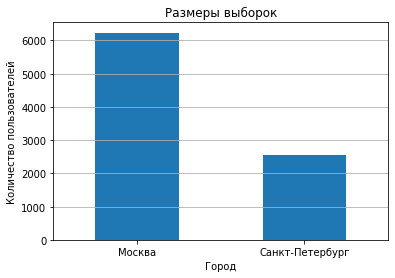

In [10]:
plt.figure(figsize=(6, 4))

group_sizes.plot(kind='bar')

plt.title('Размеры выборок')
plt.xlabel('Город')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

Размеры выборок различаются:

в Москве -- 6234 пользователя, в Санкт-Петербурге -- 2550 пользователей.
Несмотря на различие в объёмах выборок, обе группы имеют достаточно данных для применения статистических методов.

### 2.2 Сравнение статистик

In [11]:
# статистики
stats = df.groupby('city')['hours'].agg(
    count='count',
    mean='mean',
    std='std',
    median='median',
    min='min',
    max='max'
)

stats

,count,mean,std,median,min,max
city,,,,,,
Москва,6234,10.881092,36.851683,0.924498,0.000018,857.209373
Санкт-Петербург,2550,11.592691,39.704993,0.984781,0.000025,978.764775


Среднее время активности пользователей:

Москва -- 10.88 часов, а Санкт-Петербург -- 11.59 часов

Таким образом, пользователи из Санкт-Петербурга в среднем проводят больше времени в сервисе.

Однако медианные значения значительно ниже средних, что указывает на достаточно сильную асимметрию распределения. Это означает, что большинство пользователей малоактивны, а среднее значение формируется за счёт небольшой доли очень активных пользователей.

Высокие значения стандартного отклонения и наличие экстремальных значений подтверждают наличие выбросов.

### 2.3 Анализ распределения

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

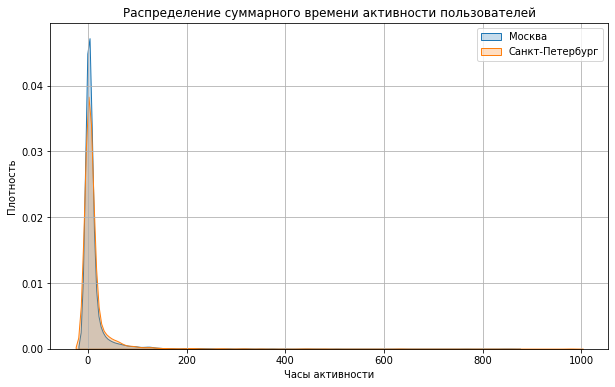

In [13]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
        data=df[df['city'] == 'Москва'], 
        x='hours', 
        label='Москва', 
        fill=True)
sns.kdeplot(
        data=df[df['city'] == 'Санкт-Петербург'], 
        x='hours', 
        label='Санкт-Петербург', 
        fill=True)

plt.title('Распределение суммарного времени активности пользователей')
plt.xlabel('Часы активности')
plt.ylabel('Плотность')
plt.grid(True)
plt.legend()
plt.show()

Распределения в обеих группах имеют выраженную асимметрию с длинным хвостом.

Форма распределений для Москвы и Санкт-Петербурга практически совпадает, и значимого визуального различия между группами не наблюдается. Значит, у пользователей в обоих городах наблюдается схожее поведение.

### 2.4 Проверка гипотезы

In [14]:
from scipy.stats import ttest_ind

# выборки
moscow = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

test_result = ttest_ind(
    spb,          # СПб
    moscow,       # Москва
    equal_var=False,
    alternative='greater'  
)

alpha = 0.05

print('p-value:', test_result.pvalue)

if test_result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 0.21823507084569593
Не получилось отвергнуть нулевую гипотезу


По результатам t-теста было получено значение p-value = 0.218, что значительно превышает уровень значимости 0.05.

Значит, не получилось отвергнуть нулевую гипотезу.

Несмотря на то, что среднее время активности пользователей в Санкт-Петербурге немного выше, это различие не является статистически значимым и может быть обусловлено случайными колебаниями данных.

## 3. Аналитическая записка

В работе была проверена гипотеза о том, что пользователи из Санкт-Петербурга в среднем проводят больше времени за просмотром контента, чем пользователи из Москвы. Для этого был использован односторонний t-тест Уэлча, так как сравниваются две независимые группы, а данные имеют выбросы и неравномерное распределение.

Уровень значимости был принят равным `alpha = 0.05`. По результатам теста было получено значение `p-value = 0.218`.

Так как p-value больше уровня значимости -- нет оснований отвергнуть нулевую гипотезу. Это значит, что разница в среднем времени активности между пользователями из Санкт-Петербурга и Москвы не является статистически значимой.

Хотя среднее значение в Санкт-Петербурге немного выше, это различие может быть случайным. Также это видно по графикам: распределения в двух городах очень похожи.

Такой результат можно объяснить тем, что в данных есть выбросы. Кроме того, поведение пользователей в двух городах в целом похоже, поэтому заметной разницы между ними не наблюдается.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Цель исследования заключается в том, чтобы оценить, повлияло ли обновление интерфейса интернет-магазина на поведение пользователей и увеличило ли конверсию в покупку.

В рамках анализа необходимо:

- проверить корректность проведения A/B-теста
- сравнить конверсию в контрольной и тестовой группах
- оценить статистическую значимость различий
- сделать вывод, был ли достигнут ожидаемый эффект.

## 2. Загрузите данные, оцените их целостность.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

### 2.1 Первичный анализ данных

In [17]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [18]:
participants.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [19]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [20]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [21]:
participants.isna().sum()

user_id    0
group      0
ab_test    0
device     0
dtype: int64

In [22]:
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64

In [23]:
print('Дубликатов до удаления:', events.duplicated().sum())

events = events.drop_duplicates()

print('Дубликатов после удаления:', events.duplicated().sum())

Дубликатов до удаления: 36318
Дубликатов после удаления: 0


На данном этапе были загружены и предварительно проанализированы две таблицы: `participants` и `events`.

Таблица `participants` содержит информацию об участниках тестов и включает 14 525 записей. В ней отсутствуют пропуски и дубликаты, что говорит о корректной структуре данных.

Таблица `event`s содержит 787 286 записей о действиях пользователей. Пропуски присутствуют только в столбце `details`, так как он не используется для всех типов событий. 

При этом в таблице `events` было обнаружено 36 318 дубликатов, которые были удалены перед дальнейшим анализом.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

### 3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

Для начала выделим пользователей, участвующих в тесте `interface_eu_test`.

In [24]:
test_name = 'interface_eu_test'

In [25]:
participants_test = participants[participants['ab_test'] == test_name].copy()

participants_test.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
2,001064FEAAB631A1,A,interface_eu_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android


In [26]:
participants_test['group'].value_counts()

B    5467
A    5383
Name: group, dtype: int64

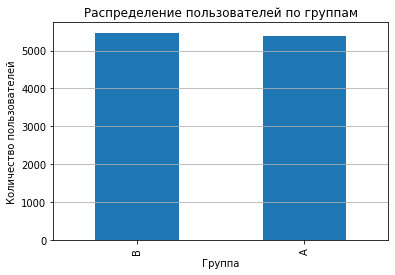

In [27]:
plt.figure(figsize=(6, 4))

participants_test['group'].value_counts().plot(kind='bar')

plt.title('Распределение пользователей по группам')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.grid(axis='y')

plt.show()

Видно, что группы имеют сопоставимые размеры. Это говорит о достаточно равномерном распределении пользователей между контрольной и тестовой группами.

In [28]:
test_users = participants_test['user_id'].unique()

user_test_counts = (
    participants[participants['user_id'].isin(test_users)]
    .groupby('user_id')['ab_test']
    .nunique()
)

bad_test_users = user_test_counts[user_test_counts > 1]
print('Пользователей, участвующих более чем в одном тесте:', len(bad_test_users))

Пользователей, участвующих более чем в одном тесте: 887


In [29]:
clean_users = user_test_counts[user_test_counts == 1].index

participants_test = participants_test[participants_test['user_id'].isin(clean_users)].copy()

Видно, что 887 пользователей участвуют одновременно более чем в одном тесте.

Это нарушает одно из главных условий корректного A/B-теста. В таком случае невозможно однозначно определить, какое именно изменение повлияло на результат.

Поэтому далее пользователи, участвующие в нескольких тестах, были исключены. 

### 3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [30]:
test_users = participants_test['user_id'].unique()

In [31]:
events_test = events[events['user_id'].isin(test_users)].copy()

events_test.head()

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [32]:
# дата регистрации 
registrations = (
    events_test[events_test['event_name'] == 'registration']
    .groupby('user_id', as_index=False)['event_dt'].min()
    .rename(columns={'event_dt': 'registration_dt'})
)

In [33]:
events_test = events_test.merge(registrations, on='user_id', how='left')

In [34]:
# лайфтайм в днях
events_test['lifetime_days'] = (events_test['event_dt'] - events_test['registration_dt']).dt.days

In [35]:
events_test_7d = events_test[(events_test['lifetime_days'] >= 0) & (events_test['lifetime_days'] <= 6)].copy()

events_test_7d.head()

,user_id,event_dt,event_name,details,registration_dt,lifetime_days
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

Для оценки достаточности выборки был использован калькулятор `Evan Miller`. 

https://www.evanmiller.org/ab-testing/sample-size.html#!30;80;5;3;0

При базовой конверсии 30%, минимальном детектируемом эффекте 3%, уровне значимости 5% и мощности 80% размер выборки составляет **3692** пользователя на группу. 

Так как в каждой группе у нас около 5400 пользовтелей, выборку можно счаитать достаточной для выявления заданного эффекта.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [36]:
events_test_7d = events_test_7d.merge(
    participants_test[['user_id', 'group']], on='user_id', how='left'
)

events_test_7d.head()

,user_id,event_dt,event_name,details,registration_dt,lifetime_days,group
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0,A
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0,A
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0,B
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0,A
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0,B


In [37]:
# все пользователи
visitors = (
    participants_test.groupby('group')['user_id'].nunique().rename('visitors')
)

In [38]:
# покупатели
buyers = (
    events_test_7d[events_test_7d['event_name'] == 'purchase']
    .groupby('group')['user_id'].nunique()
    .rename('buyers')
)

In [39]:
conversion = visitors.reset_index().merge(
    buyers.reset_index(), on='group', how='left'
)

conversion['buyers'] = conversion['buyers'].fillna(0).astype(int)
conversion['conversion'] = conversion['buyers'] / conversion['visitors']

conversion

,group,visitors,buyers,conversion
0,A,4952,1377,0.278069
1,B,5011,1480,0.295350


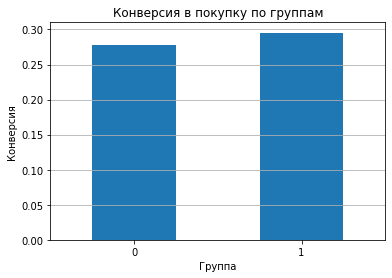

In [40]:
plt.figure(figsize=(6, 4))

conversion['conversion'].plot(kind='bar')

plt.title('Конверсия в покупку по группам')
plt.xlabel('Группа')
plt.ylabel('Конверсия')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Были рассчитаны основные метрики для обеих групп.

Конверсия в покупку: в группе A -- 27.8%, в группе B -- 29.5%.

То есть, в тестовой группе видно увеличение конверсии по сравнению с контрольной. Это может говорить о том, что новый интерфейс положительно влияет на поведение пользователей. Однако данный вывод только предварительный и требуется проверка на статистическую значимость.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

**Нулевая гипотеза:**
конверсия в тестовой группе не выше, чем в контрольной

**Альтернативная гипотеза:**
конверсия в тестовой группе выше, чем в контрольной

In [41]:
from statsmodels.stats.proportion import proportions_ztest

conversion = conversion.set_index('group')

# размеры групп 
n_a = conversion.loc['A', 'visitors']
n_b = conversion.loc['B', 'visitors']

# количество покупок
m_a = conversion.loc['A', 'buyers']
m_b = conversion.loc['B', 'buyers']

# уровень значимости
alpha = 0.05

# z-test
stat, p_value = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'  # H1: p_A < p_B
)

print('p-value:', p_value)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 0.028262547212292124
Отвергаем нулевую гипотезу


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

Для оценки различия конверсии между контрольной и тестовой группами был использован z-тест.

По результатам теста было получено значение `p-value = 0.028`, что меньше уровня значимости `0.05`. Это означает, что можно отвергнуть нулевую гипотезу и сделать вывод о том, что различие между группами является статистически значимым.

Конверсия в тестовой группе составляет `29.5%`, тогда как в контрольной -- `27.8%`. Таким образом, наблюдается рост конверсии на `1.7%`.

Однако согласно техническому заданию ожидаемый эффект должен был составить не менее `3 процентных пунктов`. Полученный прирост существенно ниже этого значения.

Следовательно, несмотря на статистическую значимость различий, ожидаемый эффект не был достигнут, и тест нельзя считать успешным.